In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4 as nc

In [11]:
fn = '/Users/jadawhite/Documents/GitHub/ISAT 420/ISAT-Semester-Project/Data/Maria_precp.nc'
ds = nc.Dataset(fn)

In [13]:
print (ds)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    GRIB_centre: ecmf
    GRIB_centreDescription: European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre: 0
    Conventions: CF-1.7
    institution: European Centre for Medium-Range Weather Forecasts
    history: 2026-04-22T20:11 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.42.0 with {"source": "tmpul1w2hyd/data.grib", "filter_by_keys": {"stream": ["oper"], "stepType": ["accum"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}
    dimensions(sizes): valid_time(120), latitude(31), longitude(81)
    variables(dimensions): int64 number(), int64 valid_time(valid_time), float64 latitude(latitude), float64 longitude(longitude), <class 'str'> expver(valid_time), float32 tp(valid_time, latitude, longitude)
    groups: 


In [17]:
df = xr.open_dataset(fn)
df

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 120, latitude: 31, longitude: 81)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2017-09-18 ... 2017-09-22T23...
  * latitude    (latitude) float64 248B 20.0 19.75 19.5 ... 13.0 12.75 12.5
  * longitude   (longitude) float64 648B -70.0 -69.75 -69.5 ... -50.25 -50.0
    number      int64 8B ...
    expver      (valid_time) <U4 2kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-22T20:11 GRIB to CDM+CF via cfgrib-0.9.1...

In [18]:
df['tp'].attrs

{'GRIB_paramId': np.int64(228),
 'GRIB_dataType': 'fc',
 'GRIB_numberOfPoints': np.int64(2511),
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': np.int64(1),
 'GRIB_stepType': 'accum',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': np.int64(0),
 'GRIB_NV': np.int64(0),
 'GRIB_Nx': np.int64(81),
 'GRIB_Ny': np.int64(31),
 'GRIB_cfName': 'unknown',
 'GRIB_cfVarName': 'tp',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25),
 'GRIB_iScansNegatively': np.int64(0),
 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25),
 'GRIB_jPointsAreConsecutive': np.int64(0),
 'GRIB_jScansPositively': np.int64(0),
 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(20.0),
 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(12.5),
 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(-70.0),
 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(-50.0),
 'GRIB_missingValue': np.float64(3.4028234663852886e+38),
 'GRIB_name':

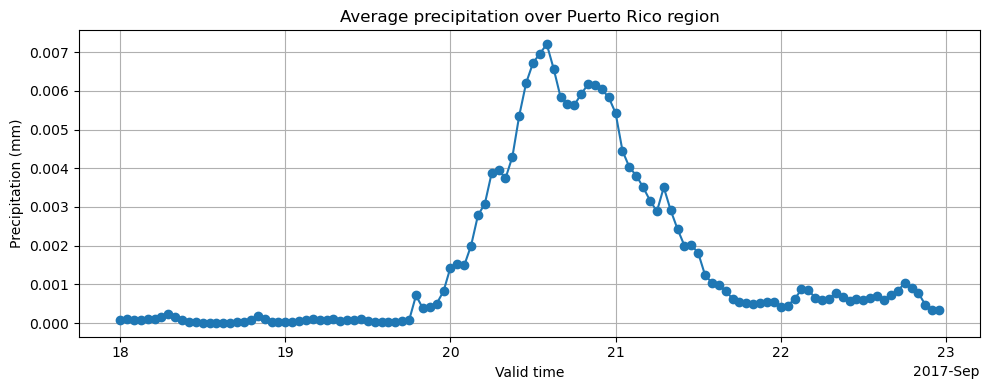

In [19]:
pr_region = df['tp'].sel(latitude=slice(19.5, 17.0), longitude=slice(-68.0, -65.0))
pr_ts = pr_region.mean(dim=['latitude', 'longitude'])

plt.figure(figsize=(10, 4))
pr_ts.plot(marker='o')
plt.title('Average precipitation over Puerto Rico region')
plt.xlabel('Valid time')
plt.ylabel('Precipitation (mm)')
plt.grid(True)
plt.tight_layout()

/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:8

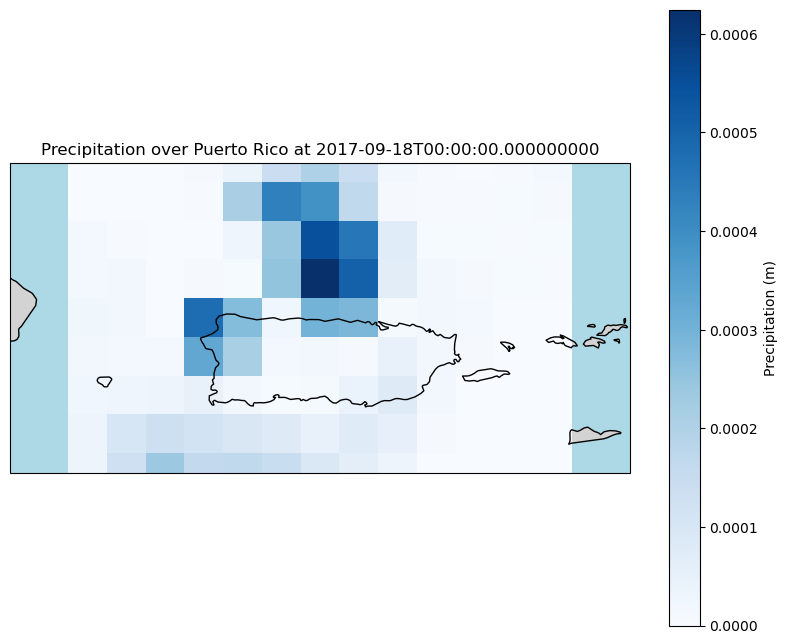

In [20]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a specific time step for plotting (e.g., the first one, or you can loop for animation)
time_step = 0  # Change this index to view different times
precip_data = pr_region.isel(valid_time=time_step)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the precipitation data
precip_data.plot(ax=ax, cmap='Blues', add_colorbar=True, cbar_kwargs={'label': 'Precipitation (m)'})

# Add geographical features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Set the extent to focus on Puerto Rico
ax.set_extent([-68.5, -64.5, 17.5, 19.5], crs=ccrs.PlateCarree())

# Add title
ax.set_title(f'Precipitation over Puerto Rico at {precip_data.valid_time.values}')

plt.show()

In [21]:
df2 = pd.read_csv('/Users/jadawhite/Documents/GitHub/ISAT 420/ISAT-Semester-Project/Data/storms.csv')

In [22]:
df2.columns

Index(['name', 'year', 'month', 'day', 'hour', 'lat', 'long', 'status',
       'category', 'wind', 'pressure', 'tropicalstorm_force_diameter',
       'hurricane_force_diameter'],
      dtype='str')

In [23]:
df2.head()

,name,year,month,day,hour,lat,long,status,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter
0,AL011975,1975,6,24,12,32.5,-52.0,tropical depression,NaN,20,-999,-1998,-1998
1,AL011975,1975,6,24,18,32.6,-52.6,tropical depression,NaN,25,-999,-1998,-1998
2,AL011975,1975,6,25,0,32.7,-53.2,tropical depression,NaN,25,-999,-1998,-1998
3,AL011975,1975,6,25,60,32.8,-53.2,tropical depression,NaN,25,-999,-1998,-1998
4,AL011975,1975,6,25,12,33.0,-54.5,tropical depression,NaN,25,-999,-1998,-1998


/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/condaenvs26/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/

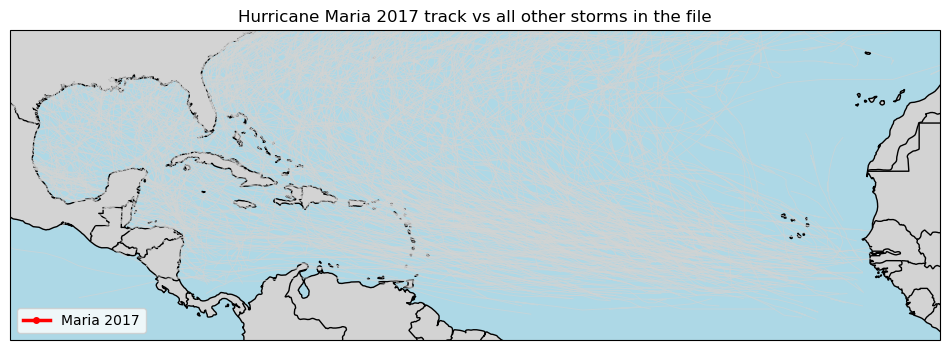

Maria 2017 observations: 0
Other storm observations: 22705


In [24]:
maria_mask = (df2['name'].str.upper() == 'MARIA') & (df2['year'] == 2017)
maria = df2[maria_mask].copy()
other = df2[~maria_mask].copy()

# Convert to datetime for sorting if needed
for df_temp in (maria, other):
    df_temp['datetime'] = pd.to_datetime(
        df_temp[['year', 'month', 'day']].assign(hour=df_temp['hour'] % 24),
        errors='coerce'
    )
    df_temp.sort_values('datetime', inplace=True)

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot all other storm tracks in gray
for (_, _), track in other.groupby(['name', 'year']):
    ax.plot(
        track['long'], track['lat'],
        color='lightgray', linewidth=0.7, alpha=0.6,
        transform=ccrs.PlateCarree()
    )

# Plot Maria 2017 track in red
ax.plot(
    maria['long'], maria['lat'],
    color='red', linewidth=2.5, marker='o', markersize=4,
    transform=ccrs.PlateCarree(),
    label='Maria 2017'
)

ax.scatter(
    maria['long'], maria['lat'],
    color='red', s=30,
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax.add_feature(cfeature.BORDERS.with_scale('50m'))
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_extent([-100, -10, 5, 35], crs=ccrs.PlateCarree())

ax.set_title('Hurricane Maria 2017 track vs all other storms in the file')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left')
plt.show()

print(f'Maria 2017 observations: {len(maria)}')
print(f'Other storm observations: {len(other)}')

In [27]:
print(df2)


                      name  year  month  day  hour   lat  long  \
0                 AL011975  1975      6   24    12  32.5 -52.0   
1                 AL011975  1975      6   24    18  32.6 -52.6   
2                 AL011975  1975      6   25     0  32.7 -53.2   
3                 AL011975  1975      6   25    60  32.8 -53.2   
4                 AL011975  1975      6   25    12  33.0 -54.5   
...                    ...   ...    ...  ...   ...   ...   ...   
22700                 Sara  2024     11   17    60  16.5 -87.5   
22701                 Sara  2024     11   17    12  16.8 -87.9   
22702                 Sara  2024     11   17    14  17.0 -88.3   
22703                 Sara  2024     11   17    18  17.4 -89.1   
22704                 Sara  2024     11   18     0  17.9 -90.2   

                    status  category  wind  pressure  \
0      tropical depression       NaN    20      -999   
1      tropical depression       NaN    25      -999   
2      tropical depression       NaN   